In [ ]:
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

datasize_attrs = {
    "L": {"color": "#005f73"},  
    "M": {"color": "#fad02c"}, 
    "S": {"color": "#780000"}
}

model_attrs = {
    "mlp": {"marker": "s", "name": "MLP"},             # square
    "logic_mlp": {"marker": "D", "name": "Logic-MLP"}, # star
    "logiknet": {"marker": "^", "name": "LogiKNet"}    # triangle
}

mpl.rcParams.update({
    "pdf.fonttype": 42,           # embed TrueType (Type 42), NOT Type 3
    "ps.fonttype": 42,
    "font.family": "serif",       # match paper fonts
    "font.serif": [
        "Times New Roman",        # macOS often has this
        "Times",
        "TeX Gyre Termes",        # fallback
        "Nimbus Roman No9 L",
        "DejaVu Serif"            # last-ditch serif fallback (not Sans)
    ],
    "text.usetex": False          # keep False unless you really need LaTeX
})

font_size = 14
font_size_axis = 12
line_width = 2

/tmp/ipykernel_2338861/1546235181.py:77: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  summary = df.groupby(["model","model_code","size","size_code","train_size"]).apply(summarize).reset_index()


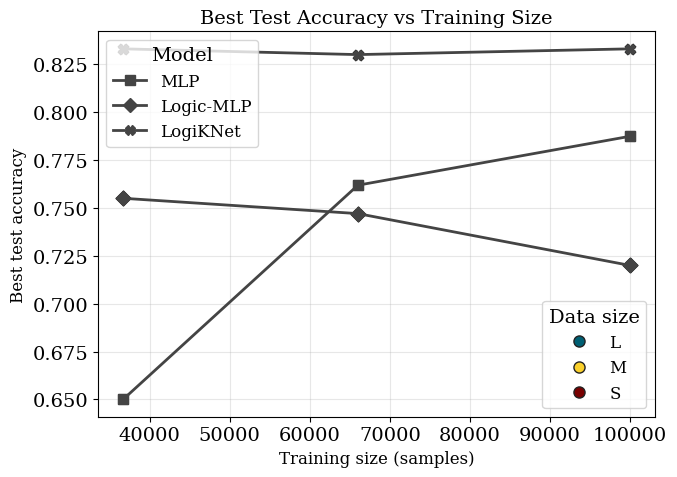

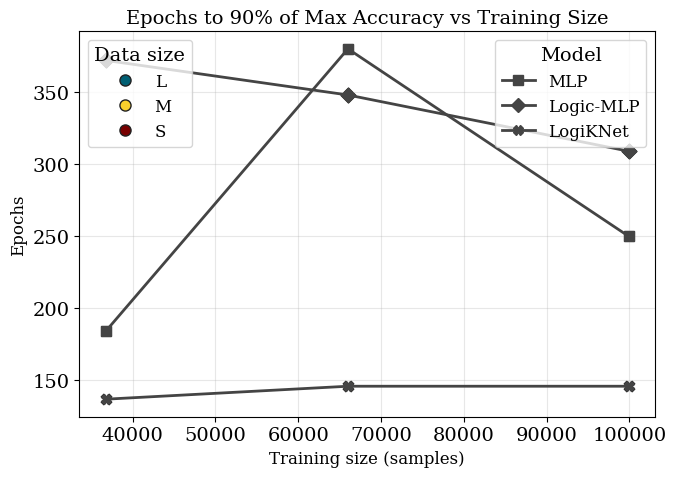

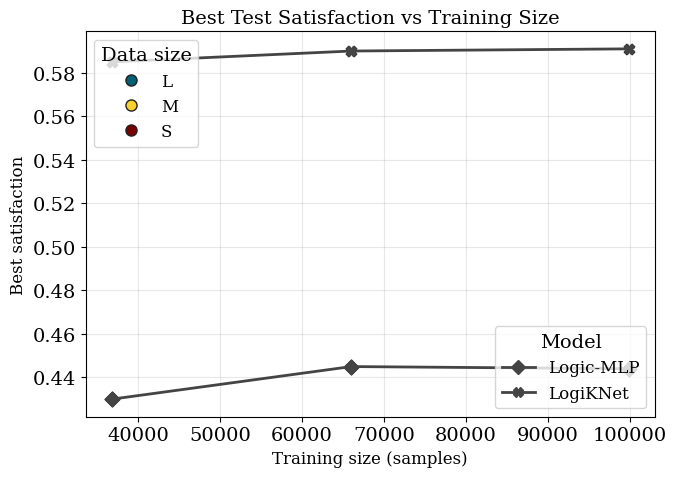

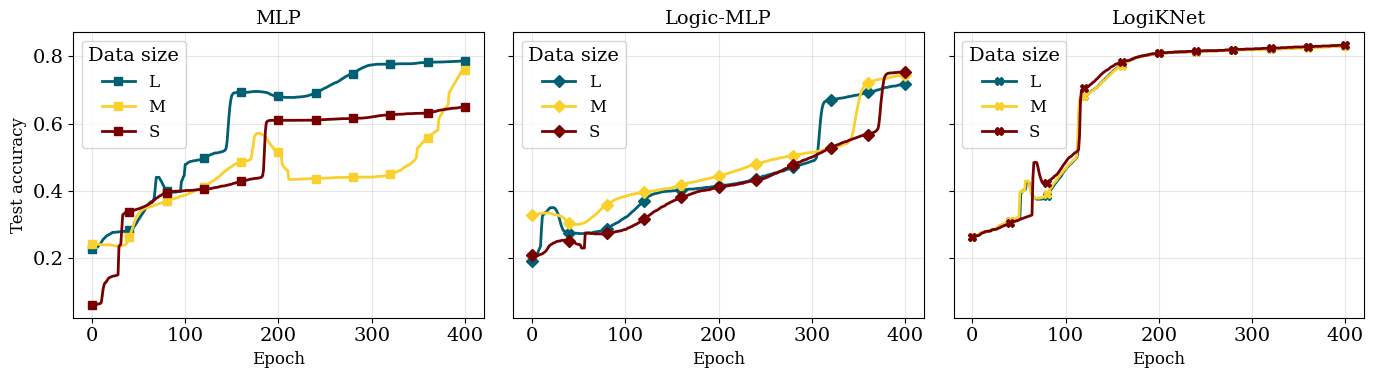

<Figure size 640x480 with 0 Axes>

In [30]:
# Paths to logs
log_paths = {
    "large": Path("/home/zyang44/Github/baseline_cicIOT/P2_featurelevel/ Compare_datasize/log_L.txt"),
    "medium": Path("/home/zyang44/Github/baseline_cicIOT/P2_featurelevel/ Compare_datasize/log_M.txt"),
    "small": Path("/home/zyang44/Github/baseline_cicIOT/P2_featurelevel/ Compare_datasize/log_S.txt"),
}

# Training set sizes
train_sizes = {"large": 99909, "medium": 66000, "small": 36720}

mlp_re   = re.compile(r"^Epoch\s+(\d+),\s+Loss:\s+([-\d.eE]+),\s+Test accuracy:\s+([-\d.eE]+)")
logic_re = re.compile(r"^Epoch\s+(\d+)\s+\|\s+Logic-MLP.*:\s+([-\d.eE]+)/([-\d.eE]+)/([-\d.eE]+)\(([-\d.eE]+)\)")
kan_re   = re.compile(r"^Epoch\s+(\d+)\s+\|\s+KAN.*:\s+([-\d.eE]+)/([-\d.eE]+)/([-\d.eE]+)\(([-\d.eE]+)\)")

records = []

def parse_one_log(size_key, path: Path):
    if not path.exists():
        print(f"Missing log: {path}")
        return
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            m = mlp_re.match(line)
            if m:
                ep = int(m.group(1))
                acc = float(m.group(3))
                records.append({
                    "size": size_key, "train_size": train_sizes[size_key],
                    "model": "MLP", "epoch": ep, "acc": acc, "sat_test": np.nan
                })
                continue
            m = logic_re.match(line)
            if m:
                ep = int(m.group(1))
                acc = float(m.group(3))
                sat_test = float(m.group(5))
                records.append({
                    "size": size_key, "train_size": train_sizes[size_key],
                    "model": "Logic-MLP", "epoch": ep, "acc": acc, "sat_test": sat_test
                })
                continue
            m = kan_re.match(line)
            if m:
                ep = int(m.group(1))
                acc = float(m.group(3))
                sat_test = float(m.group(5))
                records.append({
                    "size": size_key, "train_size": train_sizes[size_key],
                    "model": "LogiKNet", "epoch": ep, "acc": acc, "sat_test": sat_test
                })

for k, p in log_paths.items():
    parse_one_log(k, p)

df = pd.DataFrame.from_records(records)

# Map to your style keys
size_key_map  = {"large": "L", "medium": "M", "small": "S"}
model_key_map = {"MLP": "mlp", "Logic-MLP": "logic_mlp", "LogiKNet": "logiknet"}

df["size_code"]  = df["size"].map(size_key_map)
df["model_code"] = df["model"].map(model_key_map)

# Summary metrics
def summarize(group):
    best_acc = group["acc"].max()
    best_sat = group["sat_test"].max(skipna=True)
    target = 0.9 * best_acc
    g = group.sort_values("epoch")
    acc_series = g["acc"].values
    ep_series = g["epoch"].values
    idx = np.argmax(acc_series >= target) if np.any(acc_series >= target) else np.nan
    conv_epoch = ep_series[idx] if not np.isnan(idx) else np.nan
    return pd.Series({"best_acc": best_acc, "best_sat": best_sat, "conv_epoch_90pct": conv_epoch})

summary = df.groupby(["model","model_code","size","size_code","train_size"]).apply(summarize).reset_index()

# Style helpers from your config
def size_color(sz_code):
    return datasize_attrs[sz_code]["color"]

def model_marker(m_code):
    return model_attrs[m_code]["marker"]

def model_name(m_code):
    return model_attrs[m_code]["name"]

# Matplotlib font sizes
plt.rcParams.update({
    "font.size": font_size,
    "axes.labelsize": font_size_axis,
    "axes.titlesize": font_size,
    "legend.fontsize": font_size_axis
})

# Plot 1: Best accuracy vs training size
fig, ax = plt.subplots(figsize=(7,5))
for m_code in ["mlp","logic_mlp","logiknet"]:
    sub = summary[summary["model_code"] == m_code].sort_values("train_size")
    # line (neutral grey) with model-specific marker
    ax.plot(sub["train_size"], sub["best_acc"],
            marker=model_marker(m_code), markersize=7,
            color="#444444", linewidth=line_width,
            label=model_name(m_code))
    # color-coded scatter per size
    for _, row in sub.iterrows():
        ax.scatter(row["train_size"], row["best_acc"],
                   marker=model_marker(m_code), s=60,
                   facecolor=size_color(row["size_code"]),
                   edgecolor="#222222", linewidth=0.8)
# second legend for datasize colors
size_handles = [
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=size_color(s), markeredgecolor="#222222",
               markersize=8, label=s) for s in ["L","M","S"]
]
legend1 = ax.legend(title="Model", loc="upper left")
ax.add_artist(legend1)
ax.legend(handles=size_handles, title="Data size", loc="lower right")

ax.set_title("Best Test Accuracy vs Training Size")
ax.set_xlabel("Training size (samples)")
ax.set_ylabel("Best test accuracy")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 2: Epochs to 90% of max accuracy vs training size
fig, ax = plt.subplots(figsize=(7,5))
for m_code in ["mlp","logic_mlp","logiknet"]:
    sub = summary[summary["model_code"] == m_code].sort_values("train_size")
    ax.plot(sub["train_size"], sub["conv_epoch_90pct"],
            marker=model_marker(m_code), markersize=7,
            color="#444444", linewidth=line_width,
            label=model_name(m_code))
    for _, row in sub.iterrows():
        ax.scatter(row["train_size"], row["conv_epoch_90pct"],
                   marker=model_marker(m_code), s=60,
                   facecolor=size_color(row["size_code"]),
                   edgecolor="#222222", linewidth=0.8)
size_handles = [
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=size_color(s), markeredgecolor="#222222",
               markersize=8, label=s) for s in ["L","M","S"]
]
legend1 = ax.legend(title="Model", loc="upper right")
ax.add_artist(legend1)
ax.legend(handles=size_handles, title="Data size", loc="upper left")

ax.set_title("Epochs to 90% of Max Accuracy vs Training Size")
ax.set_xlabel("Training size (samples)")
ax.set_ylabel("Epochs")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 3: Best satisfaction vs training size (skip NaNs)
fig, ax = plt.subplots(figsize=(7,5))
for m_code in ["mlp","logic_mlp","logiknet"]:
    sub = summary[(summary["model_code"] == m_code) & (~summary["best_sat"].isna())].sort_values("train_size")
    if sub.empty:  # MLP has no satisfaction
        continue
    ax.plot(sub["train_size"], sub["best_sat"],
            marker=model_marker(m_code), markersize=7,
            color="#444444", linewidth=line_width,
            label=model_name(m_code))
    for _, row in sub.iterrows():
        ax.scatter(row["train_size"], row["best_sat"],
                   marker=model_marker(m_code), s=60,
                   facecolor=size_color(row["size_code"]),
                   edgecolor="#222222", linewidth=0.8)
size_handles = [
    plt.Line2D([0],[0], marker='o', color='w',
               markerfacecolor=size_color(s), markeredgecolor="#222222",
               markersize=8, label=s) for s in ["L","M","S"]
]
legend1 = ax.legend(title="Model", loc="lower right")
ax.add_artist(legend1)
ax.legend(handles=size_handles, title="Data size", loc="upper left")

ax.set_title("Best Test Satisfaction vs Training Size")
ax.set_xlabel("Training size (samples)")
ax.set_ylabel("Best satisfaction")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Plot 4: Accuracy over epochs, per model, colored by size
models_order = ["mlp","logic_mlp","logiknet"]

# fig, axes = plt.subplots(1, 3, figsize=(15,4), sharey=False)
# for i, m_code in enumerate(models_order):
#     ax = axes[i]
#     ax.set_title(model_name(m_code))
#     subm = df[df["model_code"] == m_code]
#     for s in ["L","M","S"]:
#         subs = subm[subm["size_code"] == s].sort_values("epoch")
#         ax.plot(subs["epoch"], subs["acc"],
#                 color=size_color(s), linewidth=line_width, marker=model_marker(m_code), markevery=40,
#                 label=s)
#     ax.set_xlabel("Epoch")
#     if i == 0:
#         ax.set_ylabel("Test accuracy")
#     ax.grid(True, alpha=0.3)
#     ax.legend(title="Data size")
# plt.tight_layout()
# plt.show()

# Optional smoothing (7-epoch median), same style
apply_smoothing = True
if apply_smoothing:
    # Compute global y-limits across all models/sizes using smoothed accuracy
    df_all = df.sort_values(["model_code","size_code","epoch"]).copy()
    df_all["acc_smooth_all"] = df_all.groupby(["model_code","size_code"])["acc"].transform(lambda s: s.rolling(7, min_periods=1).median())
    y_min = df_all["acc_smooth_all"].min()
    y_max = df_all["acc_smooth_all"].max()
    y_pad = 0.05 * (y_max - y_min) if np.isfinite(y_min) and np.isfinite(y_max) else 0.0
    y_min_lim = y_min - y_pad
    y_max_lim = y_max + y_pad

    fig, axes = plt.subplots(1, 3, figsize=(14,4), sharey=True)
    for i, m_code in enumerate(models_order):
        ax = axes[i]
        ax.set_title(f"{model_name(m_code)}")
        subm = df[df["model_code"] == m_code].copy()
        subm = subm.sort_values(["size_code","epoch"])
        subm["acc_smooth"] = subm.groupby("size_code")["acc"].transform(lambda s: s.rolling(7, min_periods=1).median())
        for s in ["L","M","S"]:
            subs = subm[subm["size_code"] == s]
            ax.plot(subs["epoch"], subs["acc_smooth"],
                    color=size_color(s), linewidth=line_width, marker=model_marker(m_code), markevery=40,
                    label=s)
        ax.set_xlabel("Epoch")
        if i == 0:
            ax.set_ylabel("Test accuracy")
        ax.grid(True, alpha=0.3)
        ax.legend(title="Data size")
        # Enforce consistent y-limits
        ax.set_ylim(y_min_lim, y_max_lim)
    plt.tight_layout()
    plt.show()
    plt.savefig("../output/compare-dataset.pdf", format="pdf", bbox_inches="tight")
